In [22]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
import operator
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [6]:
load_dotenv()

True

In [8]:
llm = ChatGoogleGenerativeAI(model='gemini-flash-latest')

In [4]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [9]:
def chat_node(state:ChatState):
    # take query
    messages = state['messages']

    # sent to llm
    response = llm.invoke(messages)

    # response store in state
    return {'messages':[response]}

In [21]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node',chat_node)

# add edge
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)

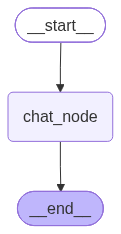

In [12]:
chatbot

In [15]:
# execute
initial_state = {'messages':[HumanMessage(content='What is the capital of Nepal')]}
chatbot.invoke(initial_state)['messages'][-1].text

'The capital of Nepal is **Kathmandu**.'

In [23]:
thread_id = '1'

while True:
    user_message = input('Type Here: ')
    print('User: ',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print("AI: ",response['messages'][-1].text)


User:  hi i am sachin
AI:  Hello Sachin! It's nice to meet you. How can I help you today?
User:  tell me who am i? my name?
AI:  Based on what you just told me, your name is **Sachin**! 

As an AI, I only know what you share with me during our conversation. So beyond your name, you are whoever you want to tell me you are! How can I help you today, Sachin?
User:  exit


In [24]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi i am sachin', additional_kwargs={}, response_metadata={}, id='3677da38-e031-4791-83bd-d5cb7ab5486a'), AIMessage(content=[{'type': 'text', 'text': "Hello Sachin! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EqQHCqEHARFNMg+tf21ocNsrLc00Ox1SKFAe+qw8RyBpkKQmCNHz/le6mzw0+fwysDyjlSh6SxLyR7nSI+6zKfjknB22PwN6F5Pgy/E1MQEhgAKjCeb3PJgyRiP/maqUM/Gm7zQRmADL+sFjPPhxqC3V88NoMi32KnjHO/gH3WLrz3YnuceeJ0V8R7RMPBEK/cDysiqwPDxkTz2YNY2Qq3qWbpVDR/pQhoHeD2mRH42j2p1NHHGO7AnHSTA5bMwwUXHbsLZg2yZDdr4tExpSy9h4dZiK+b0Sf1usCJU+KmFuUCwDLcbPIBJEbxKJwSCUZvQDnq6qiyIVz2E3JekpDxxdE2UzLH84QUpay1EMKopbVkA2b0nprvYE2A0UjWcy25lke+Nq0j0aNVoOANcG+GJd+yhblPdtGjr/ed/ws1YQF1wT3fTuFZH8PG3Ei0sOb6H/vlrJc/363wjGuMVbagav5O66sjAnqQAyj9yndT6Omz9trcxMyJn21iU0alYdUuFhQfxDqr8Sj/uUxN1KTmV08BoaTcEmnRWnf3EvoVc+LvAphzi/qHq+P4Wbo5d4FxOBv7yvpCUVWf7WZ16yvp5O3Hrjc6K/bptcwkx2Qym7elyjHMdA3fT7Zl0IDJfw1WyAfPIsmQ+5oPjDmjiE6Whh8Iu2i0/T+xTgzwX/NliE4NZljY/bf9uFARrk/iE